# Exploratory Data Analysis

## Wine Quality Dataset

In [21]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

plot_dir = Path('../plots/Eda')
plot_dir.mkdir(parents=True, exist_ok=True)

## 1. Data Loading

In [39]:
df = pd.read_csv('../data/raw/winequality-red.csv')
feature_columns = [col for col in df.columns if col != 'quality']
display(df.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 2. Dataset Overview

In [37]:
print(f'Dataset shape: {df.shape}')
print('\n')
df.info()

Dataset shape: (1599, 12)


<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


## 3. Summary Statistics

In [38]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


## 4. Data Quality Check/Missing Values

In [25]:
missing_values = df.isnull().sum().sort_values(ascending=False)
duplicate_count = df.duplicated().sum()

print('Missing values per column:')
display(missing_values.to_frame(name='missing_count'))
print(f'\nTotal duplicate rows: {duplicate_count}')

Missing values per column:


,missing_count
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0



Total duplicate rows: 240


## 5. Target Variable Analysis

`quality` = target variable 

,count
quality,
3,10
4,53
5,681
6,638
7,199
8,18


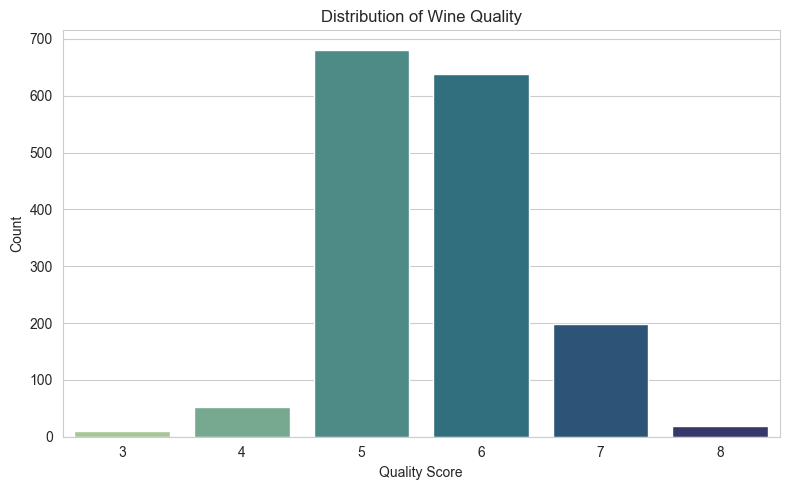

In [26]:
quality_counts = df['quality'].value_counts().sort_index()
display(quality_counts.to_frame(name='count'))

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='quality', hue='quality', palette='crest', legend=False)
plt.title('Distribution of Wine Quality')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(plot_dir / 'quality_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Univariate Analysis

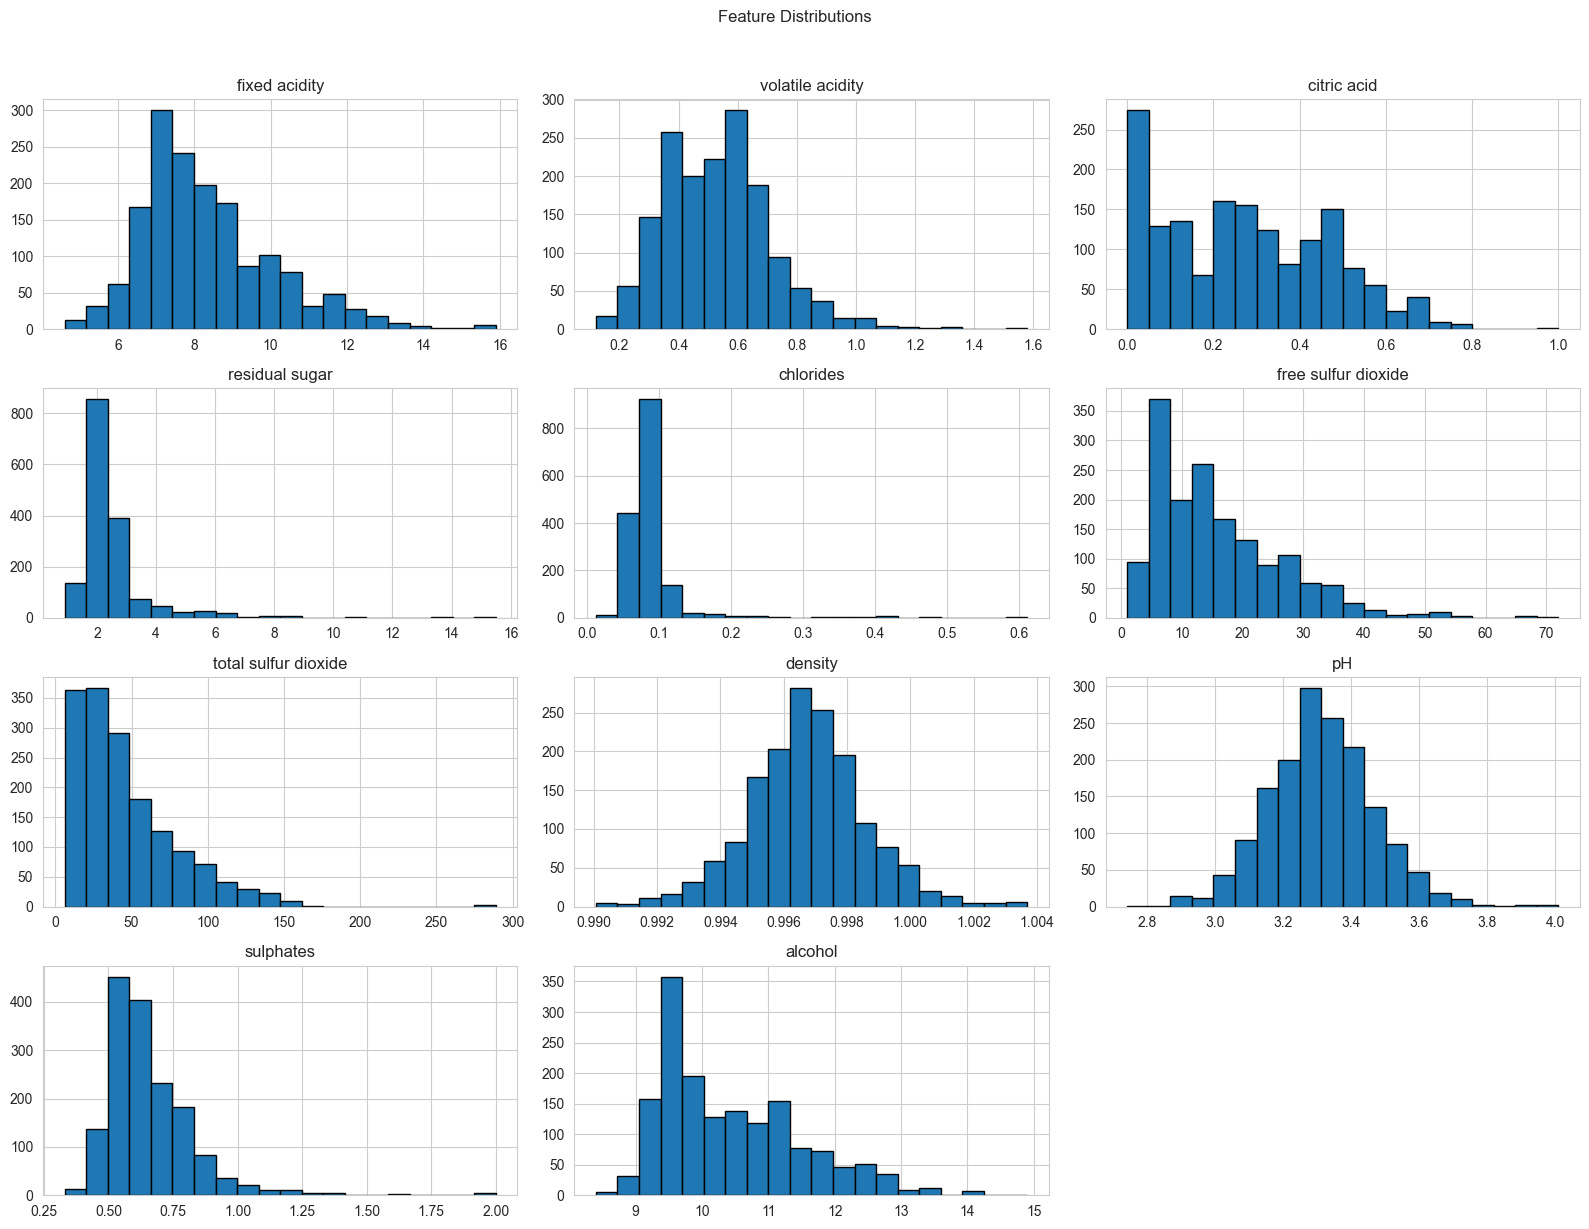

In [27]:
df[feature_columns].hist(bins=20, figsize=(16, 12), edgecolor='black')
plt.suptitle('Feature Distributions', y=1.02)
plt.tight_layout()
plt.savefig(plot_dir / 'feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Outlier Analysis

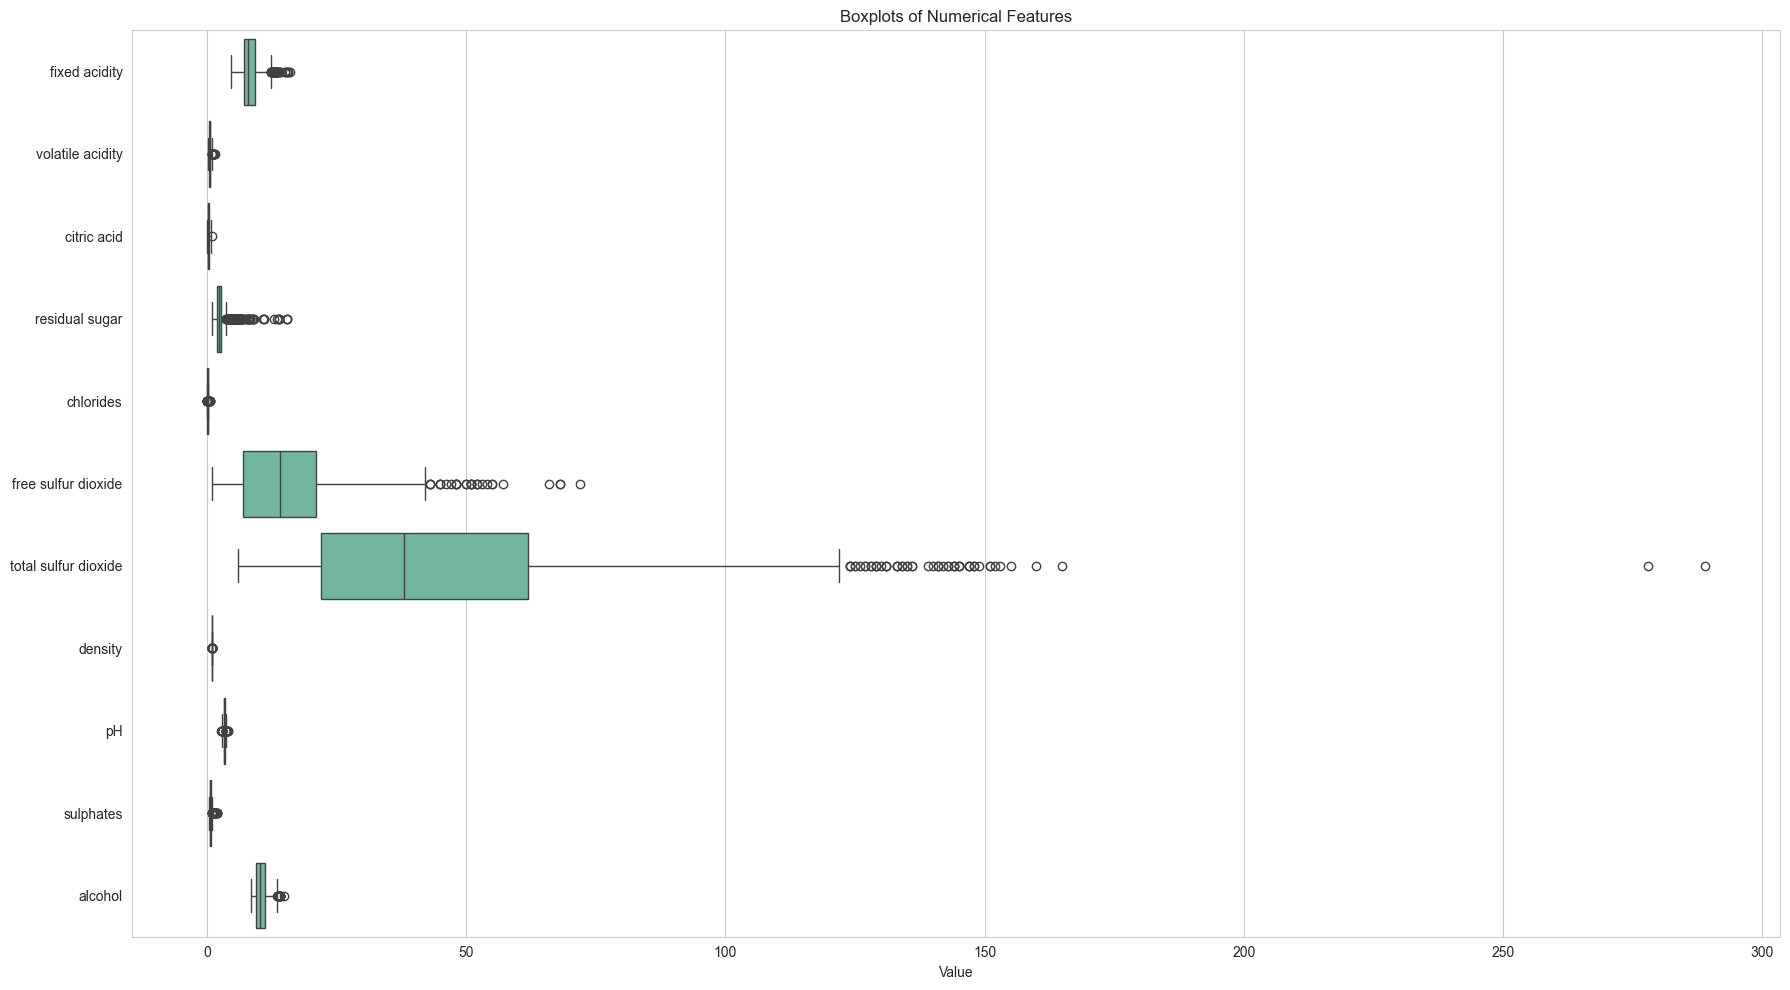

In [28]:
plt.figure(figsize=(18, 10))
sns.boxplot(data=df[feature_columns], orient='h', color=sns.color_palette('Set2')[0])
plt.title('Boxplots of Numerical Features')
plt.xlabel('Value')
plt.tight_layout()
plt.savefig(plot_dir / 'feature_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

In [29]:
outlier_summary = []

for column in feature_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    outlier_summary.append({'feature': column, 'outlier_count': outliers})

outlier_summary_df = pd.DataFrame(outlier_summary).sort_values('outlier_count', ascending=False)
display(outlier_summary_df)

,feature,outlier_count
3,residual sugar,155
4,chlorides,112
9,sulphates,59
6,total sulfur dioxide,55
0,fixed acidity,49
7,density,45
8,pH,35
5,free sulfur dioxide,30
1,volatile acidity,19
10,alcohol,13


## 8. Feature Relationship with Quality

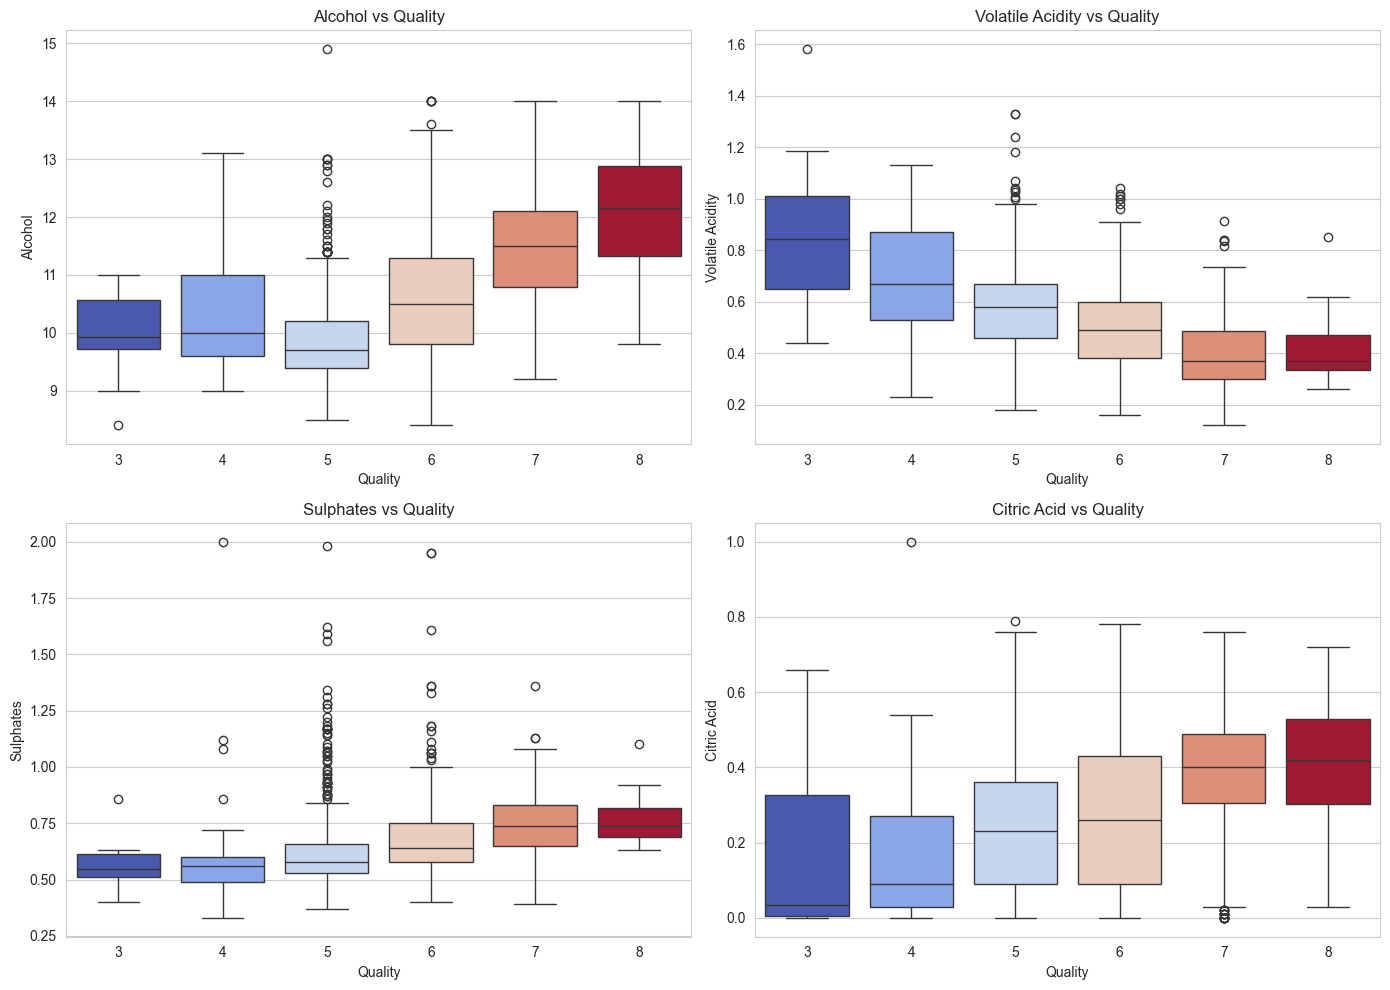

In [30]:
selected_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, feature in zip(axes, selected_features):
    sns.boxplot(data=df, x='quality', y=feature, hue='quality', palette='coolwarm', legend=False, ax=ax)
    ax.set_title(f'{feature.title()} vs Quality')
    ax.set_xlabel('Quality')
    ax.set_ylabel(feature.title())

plt.tight_layout()
plt.savefig(plot_dir / 'feature_vs_quality_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

In [40]:
quality_correlations = df.corr(numeric_only=True)['quality'].sort_values(ascending=False)
display(quality_correlations.to_frame(name='correlation_with_quality'))

,correlation_with_quality
quality,1.000000
alcohol,0.476166
sulphates,0.251397
citric acid,0.226373
fixed acidity,0.124052
residual sugar,0.013732
free sulfur dioxide,-0.050656
pH,-0.057731
chlorides,-0.128907
density,-0.174919


## 9. Correlation Analysis

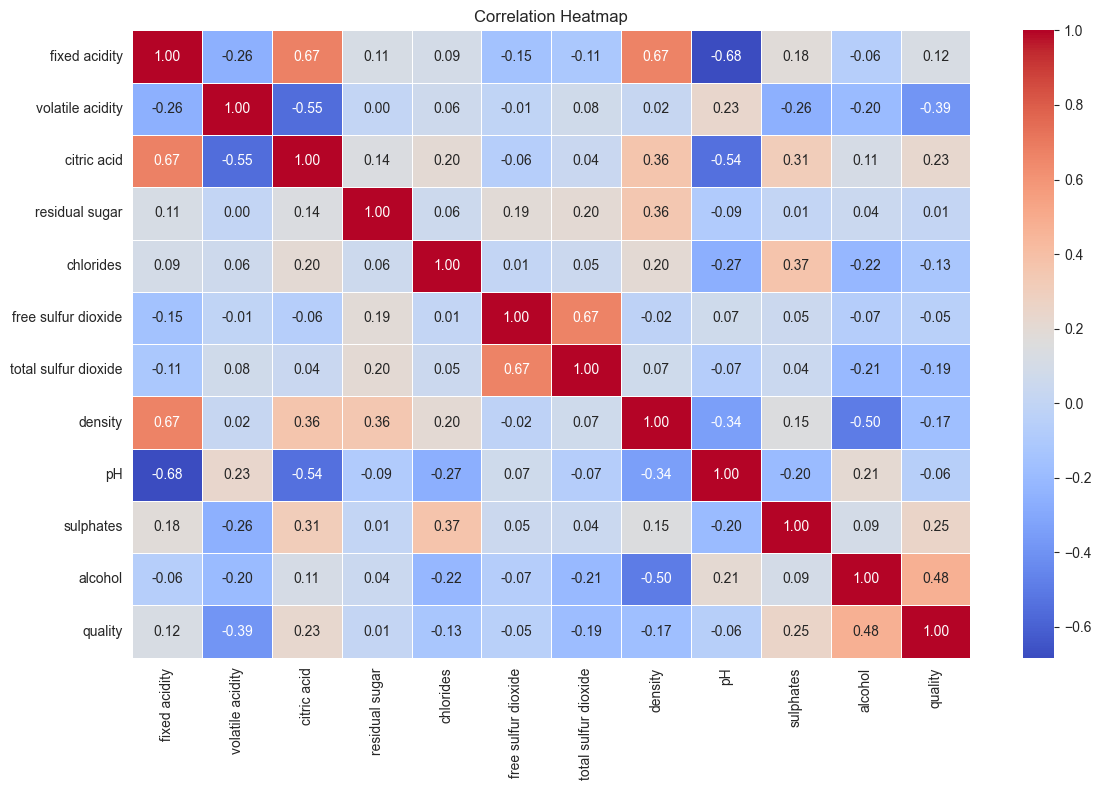

In [41]:
plt.figure(figsize=(12, 8))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig(plot_dir / 'correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()